<a href="https://colab.research.google.com/github/Manojmp7676/NATURAL-LANGUAGE-PROCESSING-NLP-/blob/main/Project_7_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub nltk textblob wordcloud

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
path = kagglehub.dataset_download("jiashenliu/515k-hotel-reviews-data-in-europe")

print("Dataset downloaded to:", path)

100%|██████████| 45.1M/45.1M [00:02<00:00, 16.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/jiashenliu/515k-hotel-reviews-data-in-europe/versions/1


In [4]:
import os

print(os.listdir(path))

['Hotel_Reviews.csv']


In [5]:
df = pd.read_csv(os.path.join(path, "Hotel_Reviews.csv"))

In [7]:
df.head()


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [8]:
print(df.shape)
print(df.columns)

(515738, 17)
Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')


In [9]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df["Clean_Review"] = df["Positive_Review"].apply(preprocess)

df[["Positive_Review","Clean_Review"]].head()

,Positive_Review,Clean_Review
0,Only the park outside of the hotel was beauti...,park outside hotel beautiful
1,No real complaints the hotel was great great ...,real complaint hotel great great location surr...
2,Location was good and staff were ok It is cut...,location good staff ok cute hotel breakfast ra...
3,Great location in nice surroundings the bar a...,great location nice surroundings bar restauran...
4,Amazing location and building Romantic setting,amazing location building romantic setting


In [10]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

df["Sentiment"].value_counts()

,count
Sentiment,
Positive,430872
Neutral,77548
Negative,7318


In [11]:
issues = [
    "room",
    "clean",
    "staff",
    "food",
    "breakfast",
    "wifi",
    "location",
    "bathroom",
    "service"
]

for issue in issues:
    df[issue] = df["Clean_Review"].str.contains(issue)

for issue in issues:
    print(issue, ":", df[issue].sum())

room : 162500
clean : 74241
staff : 189481
food : 16406
breakfast : 82647
wifi : 7166
location : 189531
bathroom : 18527
service : 26381


In [12]:
print("========== CUSTOMER SATISFACTION REPORT ==========")

print("\nTotal Reviews:", len(df))

print("\nSentiment Distribution")

print(df["Sentiment"].value_counts())

print("\nAverage Hotel Rating")

print(df["Reviewer_Score"].mean())

print("\nTop Service Issues")

for issue in issues:
    print(issue, ":", df[issue].sum())

========== CUSTOMER SATISFACTION REPORT ==========

Total Reviews: 515738

Sentiment Distribution
Sentiment
Positive    430872
Neutral      77548
Negative      7318
Name: count, dtype: int64

Average Hotel Rating
8.395076569886262

Top Service Issues
room : 162500
clean : 74241
staff : 189481
food : 16406
breakfast : 82647
wifi : 7166
location : 189531
bathroom : 18527
service : 26381


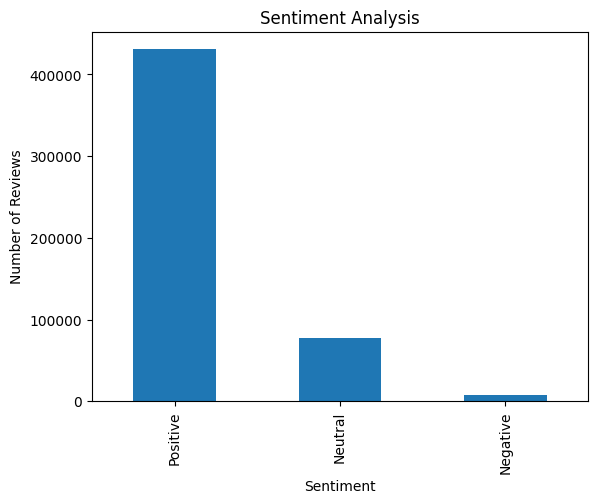

In [13]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

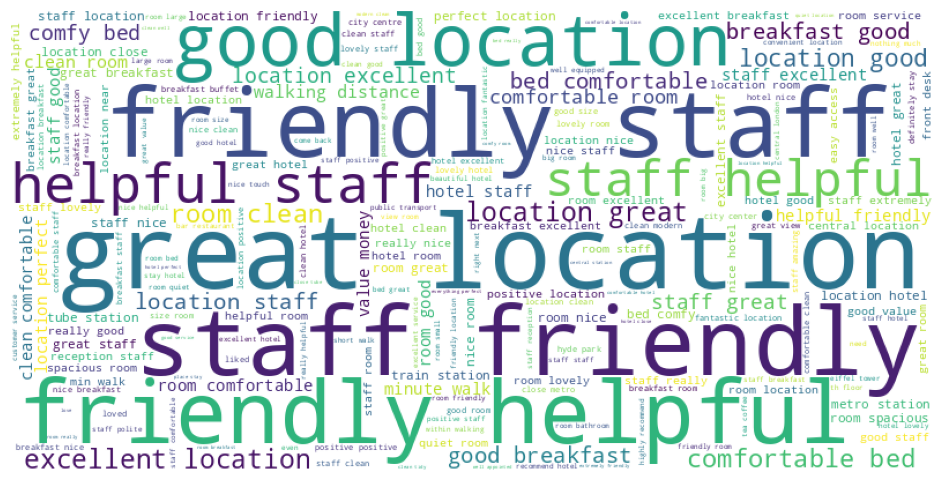

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Clean_Review"])

wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()